# Eye Liquid Spread Analysis - Data Processing

This notebook processes raw image data and generates measurements for analysis.

**Data structure:**
- Each case is in a zipped folder in `./data/`
- Slide1: Calibration image (red circle with 3.3 cm diameter)
- Slide2: Time 0
- Slide3+: Subsequent images at 0.25 second intervals (4 fps)

**Outputs:**
- `results/eye_liquid_spread_measurements.csv` - Area, velocity, group assignments for all cases
- `results/calibration_data.csv` - Calibration data per case
- `results/area_by_time_case.csv` - Area pivoted by time and case

**Note:** All `.zip` files in the data folder will be processed automatically.

In [1]:
import zipfile
import re
import os
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Configuration
DATA_DIR = Path('./data')
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

CALIBRATION_DIAMETER_CM = 3.3  # Known diameter of calibration circle in cm
TIME_INTERVAL_SEC = 0.25  # Time between images in seconds (4 fps)

## Helper Functions

In [3]:
def detect_red_pixels(img_array, r_thresh=150, g_thresh=100, b_thresh=100):
    """
    Detect red pixels in an image.
    """
    r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
    red_mask = (r > r_thresh) & (g < g_thresh) & (b < b_thresh)
    return red_mask


def get_calibration_factor(calibration_img, diameter_cm=CALIBRATION_DIAMETER_CM):
    """
    Calculate the calibration factor (pixels per cm²) from the calibration image.
    """
    red_mask = detect_red_pixels(calibration_img)
    coords = np.column_stack(np.where(red_mask))
    if len(coords) == 0:
        raise ValueError("No red pixels found in calibration image")
    
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    diameter_pixels = ((x_max - x_min + 1) + (y_max - y_min + 1)) / 2
    pixels_per_cm = diameter_pixels / diameter_cm
    pixels_per_cm_squared = pixels_per_cm ** 2
    
    return pixels_per_cm_squared, diameter_pixels, pixels_per_cm


def calculate_red_area_cm2(img_array, pixels_per_cm_squared):
    """
    Calculate the area of red pixels in cm².
    """
    red_mask = detect_red_pixels(img_array)
    red_pixel_count = np.sum(red_mask)
    area_cm2 = red_pixel_count / pixels_per_cm_squared
    return area_cm2, red_pixel_count

In [4]:
def natural_sort_key(filename):
    """
    Generate a key for natural sorting of filenames like Slide1, Slide2, ..., Slide10.
    """
    if isinstance(filename, Path):
        filename = filename.name
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', str(filename))]


def process_case(zip_path):
    """
    Process a single case (zip file) and return area measurements over time.
    """
    case_name = zip_path.stem
    print(f"\nProcessing {case_name}...")
    
    measurements = []
    
    with zipfile.ZipFile(zip_path, 'r') as zf:
        png_files = [f for f in zf.namelist() 
                     if f.lower().endswith('.png') and not f.startswith('__MACOSX')]
        png_files.sort(key=natural_sort_key)
        
        print(f"  Found {len(png_files)} images")
        
        if len(png_files) < 2:
            raise ValueError(f"Not enough images in {case_name}")
        
        with zf.open(png_files[0]) as f:
            calibration_img = np.array(Image.open(BytesIO(f.read())))
        
        pixels_per_cm_squared, diameter_pixels, pixels_per_cm = get_calibration_factor(calibration_img)
        
        calibration_info = {
            'case': case_name,
            'diameter_pixels': diameter_pixels,
            'pixels_per_cm': pixels_per_cm,
            'pixels_per_cm_squared': pixels_per_cm_squared
        }
        
        print(f"  Calibration: {diameter_pixels:.1f} pixels diameter = {CALIBRATION_DIAMETER_CM} cm")
        print(f"  Scale: {pixels_per_cm:.2f} px/cm, {pixels_per_cm_squared:.2f} px/cm²")
        
        for i, img_file in enumerate(png_files[1:]):
            time_sec = i * TIME_INTERVAL_SEC
            
            with zf.open(img_file) as f:
                img_array = np.array(Image.open(BytesIO(f.read())))
            
            area_cm2, pixel_count = calculate_red_area_cm2(img_array, pixels_per_cm_squared)
            
            measurements.append({
                'case': case_name,
                'slide': img_file,
                'time_sec': time_sec,
                'area_cm2': area_cm2,
                'red_pixel_count': pixel_count
            })
        
        print(f"  Processed {len(measurements)} time points")
        print(f"  Time range: {measurements[0]['time_sec']:.2f}s to {measurements[-1]['time_sec']:.2f}s")
        print(f"  Area range: {measurements[0]['area_cm2']:.3f} to {measurements[-1]['area_cm2']:.3f} cm²")
    
    return measurements, calibration_info

## Process All Cases

In [5]:
# Find ALL zip files in the data directory
zip_files = sorted(DATA_DIR.glob('*.zip'), key=natural_sort_key)

print(f"Found {len(zip_files)} case files in {DATA_DIR}:")
for zf in zip_files:
    print(f"  - {zf.name}")

if len(zip_files) == 0:
    raise FileNotFoundError(f"No .zip files found in {DATA_DIR}. Please add case folders.")

Found 23 case files in data:
  - Case#1.zip
  - Case#2.zip
  - Case#3.zip
  - Case#4.zip
  - Case#5.zip
  - Case#6.zip
  - Case#7.zip
  - Case#8.zip
  - Case#9.zip
  - Case#10.zip
  - Case#11.zip
  - Case#12.zip
  - Case#13.zip
  - Case#14.zip
  - Case#15.zip
  - Case#16.zip
  - Case#17.zip
  - Case#18.zip
  - Case#19.zip
  - Case#20.zip
  - Case#21.zip
  - Case#22.zip
  - Case#23.zip


In [6]:
# Process all cases
all_measurements = []
all_calibrations = []

for zip_path in zip_files:
    try:
        measurements, calibration_info = process_case(zip_path)
        all_measurements.extend(measurements)
        all_calibrations.append(calibration_info)
    except Exception as e:
        print(f"  ERROR processing {zip_path.name}: {e}")

print(f"\n{'='*50}")
print(f"Successfully processed {len(all_calibrations)} cases")
print(f"Total measurements: {len(all_measurements)}")


Processing Case#1...
  Found 33 images
  Calibration: 480.5 pixels diameter = 3.3 cm
  Scale: 145.61 px/cm, 21201.12 px/cm²


  Processed 32 time points
  Time range: 0.00s to 7.75s
  Area range: 1.455 to 3.097 cm²

Processing Case#2...
  Found 42 images
  Calibration: 269.5 pixels diameter = 3.3 cm
  Scale: 81.67 px/cm, 6669.44 px/cm²
  Processed 41 time points
  Time range: 0.00s to 10.00s
  Area range: 0.956 to 2.388 cm²

Processing Case#3...
  Found 42 images
  Calibration: 263.5 pixels diameter = 3.3 cm
  Scale: 79.85 px/cm, 6375.78 px/cm²
  Processed 41 time points
  Time range: 0.00s to 10.00s
  Area range: 0.543 to 3.356 cm²

Processing Case#4...
  Found 42 images
  Calibration: 265.5 pixels diameter = 3.3 cm
  Scale: 80.45 px/cm, 6472.93 px/cm²
  Processed 41 time points
  Time range: 0.00s to 10.00s
  Area range: 1.651 to 3.623 cm²

Processing Case#5...
  Found 42 images
  Calibration: 262.5 pixels diameter = 3.3 cm
  Scale: 79.55 px/cm, 6327.48 px/cm²
  Processed 41 time points
  Time range: 0.00s to 10.00s
  Area range: 1.280 to 2.970 cm²

Processing Case#6...
  Found 42 images
  Calibration: 265.

In [7]:
# Create DataFrames
df_areas = pd.DataFrame(all_measurements)
df_calibration = pd.DataFrame(all_calibrations)

print("df_areas:")
display(df_areas)

print("\nCalibration Summary:")
display(df_calibration)

df_areas:


,case,slide,time_sec,area_cm2,red_pixel_count
0,Case#1,Slide2.png,0.00,1.455394,30856
1,Case#1,Slide3.png,0.25,1.641941,34811
2,Case#1,Slide4.png,0.50,1.845374,39124
3,Case#1,Slide5.png,0.75,1.999564,42393
4,Case#1,Slide6.png,1.00,2.154555,45679
...,...,...,...,...,...
929,Case#23,Slide38.png,9.00,3.034036,7177
930,Case#23,Slide39.png,9.25,3.140990,7430
931,Case#23,Slide40.png,9.50,3.129999,7404
932,Case#23,Slide41.png,9.75,3.099984,7333



Calibration Summary:


,case,diameter_pixels,pixels_per_cm,pixels_per_cm_squared
0,Case#1,480.5,145.606061,21201.124885
1,Case#2,269.5,81.666667,6669.444444
2,Case#3,263.5,79.848485,6375.780533
3,Case#4,265.5,80.454545,6472.933884
4,Case#5,262.5,79.545455,6327.479339
5,Case#6,265.5,80.454545,6472.933884
6,Case#7,264.0,80.000000,6400.000000
7,Case#8,209.5,63.484848,4030.325987
8,Case#9,208.0,63.030303,3972.819100
9,Case#10,238.5,72.272727,5223.347107


## Velocity Computation

Calculate the rate of area change (velocity) between consecutive time points.

In [8]:
# Compute velocity
df_areas['velocity_cm2_per_sec'] = df_areas.groupby('case')['area_cm2'].diff() / TIME_INTERVAL_SEC

print("Area and Velocity measurements:")
display(df_areas[['case', 'time_sec', 'area_cm2', 'velocity_cm2_per_sec']])

Area and Velocity measurements:


,case,time_sec,area_cm2,velocity_cm2_per_sec
0,Case#1,0.00,1.455394,NaN
1,Case#1,0.25,1.641941,0.746187
2,Case#1,0.50,1.845374,0.813730
3,Case#1,0.75,1.999564,0.616760
4,Case#1,1.00,2.154555,0.619967
...,...,...,...,...
929,Case#23,9.00,3.034036,-0.196153
930,Case#23,9.25,3.140990,0.427817
931,Case#23,9.50,3.129999,-0.043965
932,Case#23,9.75,3.099984,-0.120059


## Group Assignment

Load group assignments from Excel file and assign to each case.

In [9]:
# Load and parse groups from Excel file
groups_file = DATA_DIR / 'groups.xlsx'

if groups_file.exists():
    df_groups_raw = pd.read_excel(groups_file, header=None)
    
    # Parse: Row 1 has group names, Rows 2+ have case numbers
    group_names = df_groups_raw.iloc[1, 1:].tolist()
    
    case_to_group = {}
    for col_idx, group_name in enumerate(group_names, start=1):
        if pd.isna(group_name):
            continue
        case_numbers = df_groups_raw.iloc[2:, col_idx].dropna().astype(int).tolist()
        for case_num in case_numbers:
            case_to_group[f"Case#{case_num}"] = group_name
    
    print("Group assignments:")
    for case, group in sorted(case_to_group.items(), key=lambda x: natural_sort_key(x[0])):
        print(f"  {case}: {group}")
    
    # Assign groups to dataframe
    df_areas['group'] = df_areas['case'].map(case_to_group)
else:
    print(f"Warning: {groups_file} not found. Group assignments will be missing.")
    df_areas['group'] = None

Group assignments:
  Case#1: CONTROL
  Case#2: GLAUCOMA - URAMOX
  Case#3: CONTROL
  Case#4: CONTROL
  Case#5: CONTROL
  Case#6: CONTROL
  Case#7: CONTROL
  Case#8: CONTROL
  Case#9: CONTROL
  Case#10: GLAUCOMA + URAMOX
  Case#11: GLAUCOMA - URAMOX
  Case#12: GLAUCOMA + URAMOX
  Case#13: GLAUCOMA + URAMOX
  Case#14: GLAUCOMA + URAMOX
  Case#15: GLAUCOMA + URAMOX
  Case#16: GLAUCOMA + URAMOX
  Case#17: GLAUCOMA + URAMOX
  Case#18: GLAUCOMA + URAMOX
  Case#19: GLAUCOMA - URAMOX
  Case#20: GLAUCOMA + URAMOX
  Case#21: GLAUCOMA + URAMOX
  Case#22: GLAUCOMA - URAMOX
  Case#23: GLAUCOMA - URAMOX


In [10]:
# Compute summary statistics per case
case_stats = df_areas.groupby('case').agg(
    group=('group', 'first'),
    final_area=('area_cm2', 'last'),
    initial_area=('area_cm2', 'first'),
    area_change=('area_cm2', lambda x: x.iloc[-1] - x.iloc[0]),
    mean_velocity=('velocity_cm2_per_sec', 'mean'),
    max_velocity=('velocity_cm2_per_sec', 'max'),
    min_velocity=('velocity_cm2_per_sec', 'min')
).round(4)

print("="*70)
print("CASE STATISTICS SUMMARY")
print("="*70)

# Final Area
print("\n--- FINAL AREA ---")
max_area_case = case_stats['final_area'].idxmax()
min_area_case = case_stats['final_area'].idxmin()
print(f"Largest final area:  {max_area_case} ({case_stats.loc[max_area_case, 'group']}) = {case_stats.loc[max_area_case, 'final_area']:.3f} cm²")
print(f"Smallest final area: {min_area_case} ({case_stats.loc[min_area_case, 'group']}) = {case_stats.loc[min_area_case, 'final_area']:.3f} cm²")
print(f"Mean final area: {case_stats['final_area'].mean():.3f} ± {case_stats['final_area'].std():.3f} cm²")

# Area Change (spread)
print("\n--- AREA CHANGE (Final - Initial) ---")
max_change_case = case_stats['area_change'].idxmax()
min_change_case = case_stats['area_change'].idxmin()
print(f"Largest area change:  {max_change_case} ({case_stats.loc[max_change_case, 'group']}) = {case_stats.loc[max_change_case, 'area_change']:.3f} cm²")
print(f"Smallest area change: {min_change_case} ({case_stats.loc[min_change_case, 'group']}) = {case_stats.loc[min_change_case, 'area_change']:.3f} cm²")
print(f"Mean area change: {case_stats['area_change'].mean():.3f} ± {case_stats['area_change'].std():.3f} cm²")

# Mean Velocity
print("\n--- MEAN VELOCITY ---")
max_mean_vel_case = case_stats['mean_velocity'].idxmax()
min_mean_vel_case = case_stats['mean_velocity'].idxmin()
print(f"Highest mean velocity: {max_mean_vel_case} ({case_stats.loc[max_mean_vel_case, 'group']}) = {case_stats.loc[max_mean_vel_case, 'mean_velocity']:.4f} cm²/sec")
print(f"Lowest mean velocity:  {min_mean_vel_case} ({case_stats.loc[min_mean_vel_case, 'group']}) = {case_stats.loc[min_mean_vel_case, 'mean_velocity']:.4f} cm²/sec")
print(f"Mean of mean velocities: {case_stats['mean_velocity'].mean():.4f} ± {case_stats['mean_velocity'].std():.4f} cm²/sec")

# Max Velocity (Peak)
print("\n--- PEAK VELOCITY ---")
max_peak_vel_case = case_stats['max_velocity'].idxmax()
min_peak_vel_case = case_stats['max_velocity'].idxmin()
print(f"Highest peak velocity: {max_peak_vel_case} ({case_stats.loc[max_peak_vel_case, 'group']}) = {case_stats.loc[max_peak_vel_case, 'max_velocity']:.4f} cm²/sec")
print(f"Lowest peak velocity:  {min_peak_vel_case} ({case_stats.loc[min_peak_vel_case, 'group']}) = {case_stats.loc[min_peak_vel_case, 'max_velocity']:.4f} cm²/sec")
print(f"Mean of peak velocities: {case_stats['max_velocity'].mean():.4f} ± {case_stats['max_velocity'].std():.4f} cm²/sec")

print("\n" + "="*70)
print("\nFull case statistics table:")
display(case_stats.sort_values('final_area', ascending=False))

CASE STATISTICS SUMMARY

--- FINAL AREA ---
Largest final area:  Case#15 (GLAUCOMA + URAMOX) = 4.180 cm²
Smallest final area: Case#19 (GLAUCOMA - URAMOX) = 1.199 cm²
Mean final area: 3.060 ± 0.587 cm²

--- AREA CHANGE (Final - Initial) ---
Largest area change:  Case#3 (CONTROL) = 2.812 cm²
Smallest area change: Case#19 (GLAUCOMA - URAMOX) = 0.804 cm²
Mean area change: 2.026 ± 0.453 cm²

--- MEAN VELOCITY ---
Highest mean velocity: Case#3 (CONTROL) = 0.2812 cm²/sec
Lowest mean velocity:  Case#19 (GLAUCOMA - URAMOX) = 0.0804 cm²/sec
Mean of mean velocities: 0.2047 ± 0.0446 cm²/sec

--- PEAK VELOCITY ---
Highest peak velocity: Case#3 (CONTROL) = 2.6274 cm²/sec
Lowest peak velocity:  Case#20 (GLAUCOMA + URAMOX) = 0.6083 cm²/sec
Mean of peak velocities: 1.1688 ± 0.4513 cm²/sec


Full case statistics table:


,group,final_area,initial_area,area_change,mean_velocity,max_velocity,min_velocity
case,,,,,,,
Case#15,GLAUCOMA + URAMOX,4.1804,1.4563,2.7242,0.2724,1.5349,-0.3645
Case#9,CONTROL,3.8157,1.9346,1.8810,0.1881,0.7571,-0.1742
Case#8,CONTROL,3.6406,1.6170,2.0237,0.2024,0.9141,-0.2660
Case#4,CONTROL,3.6228,1.6512,1.9716,0.1972,1.1074,-0.3461
Case#11,GLAUCOMA - URAMOX,3.4597,1.2446,2.2151,0.2215,1.4616,-0.0874
Case#7,CONTROL,3.4492,1.0591,2.3902,0.2390,1.2600,-0.2169
Case#16,GLAUCOMA + URAMOX,3.4125,1.0196,2.3929,0.2393,1.3672,-0.2661
Case#3,CONTROL,3.3557,0.5433,2.8124,0.2812,2.6274,-0.1857
Case#13,GLAUCOMA + URAMOX,3.1296,1.1797,1.9499,0.1950,1.2492,-0.0386


In [11]:
# Create condition column: GLAUCOMA (all) vs CONTROL
df_areas['condition'] = df_areas['group'].apply(
    lambda x: 'CONTROL' if x == 'CONTROL' else 'GLAUCOMA' if pd.notna(x) else None
)

print("Cases per group:")
display(df_areas.groupby('group')['case'].nunique().rename('n_cases'))

print("\nCases per condition:")
display(df_areas.groupby('condition')['case'].nunique().rename('n_cases'))

Cases per group:


group
CONTROL               8
GLAUCOMA + URAMOX    10
GLAUCOMA - URAMOX     5
Name: n_cases, dtype: int64


Cases per condition:


condition
CONTROL      8
GLAUCOMA    15
Name: n_cases, dtype: int64

## Preview Data

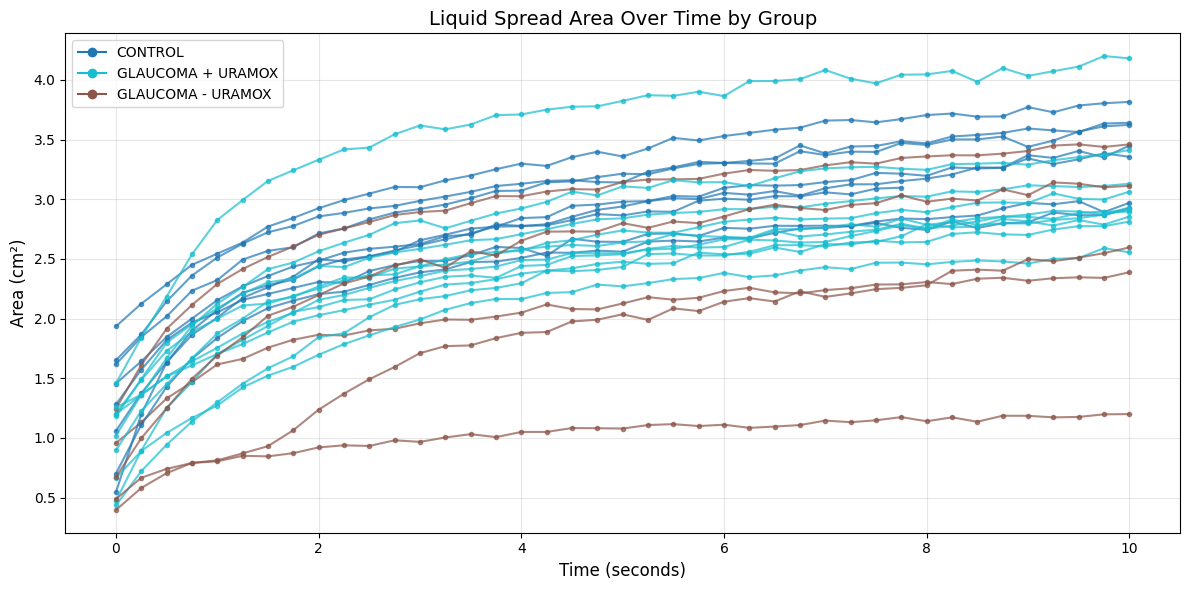

In [12]:
# Plot area over time for all cases (colored by group)
groups = df_areas['group'].dropna().unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
group_colors = dict(zip(groups, colors))
LABEL_MAP = {'CONTROL': 'control', 'GLAUCOMA + URAMOX': 'glaucoma + Uramox', 'GLAUCOMA - URAMOX': 'glaucoma - Uramox'}

plt.figure(figsize=(12, 6))

for case in df_areas['case'].unique():
    case_data = df_areas[df_areas['case'] == case]
    group = case_data['group'].iloc[0]
    color = group_colors.get(group, 'gray')
    plt.plot(case_data['time_sec'], case_data['area_cm2'], 'o-', 
             color=color, markersize=3, alpha=0.7)

# Add legend
for group in sorted(groups):
    plt.plot([], [], 'o-', color=group_colors[group], label=LABEL_MAP.get(group, group))

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Area (cm²)', fontsize=12)
plt.title('Liquid Spread Area Over Time by Group', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot velocity over time for all cases
plt.figure(figsize=(12, 6))

for case in df_areas['case'].unique():
    case_data = df_areas[df_areas['case'] == case]
    group = case_data['group'].iloc[0]
    color = group_colors.get(group, 'gray')
    plt.plot(case_data['time_sec'], case_data['velocity_cm2_per_sec'], 'o-', 
             color=color, markersize=3, alpha=0.7)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Velocity (cm²/sec)', fontsize=12)
plt.title('Rate of Area Change (Velocity) Over Time', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Results

In [14]:
# Save main measurements file
output_path = RESULTS_DIR / 'eye_liquid_spread_measurements.csv'
df_areas.to_csv(output_path, index=False)
print(f"Saved measurements to: {output_path}")

# Save calibration data
calibration_path = RESULTS_DIR / 'calibration_data.csv'
df_calibration.to_csv(calibration_path, index=False)
print(f"Saved calibration data to: {calibration_path}")

# Save area pivoted by time and case
df_area_pivot = df_areas.pivot_table(index='time_sec', columns='case', values='area_cm2')
area_pivot_path = RESULTS_DIR / 'area_by_time_case.csv'
df_area_pivot.to_csv(area_pivot_path)
print(f"Saved area pivot table to: {area_pivot_path}")

Saved measurements to: results\eye_liquid_spread_measurements.csv
Saved calibration data to: results\calibration_data.csv
Saved area pivot table to: results\area_by_time_case.csv


In [15]:
# Summary
print("\n" + "="*60)
print("DATA PROCESSING COMPLETE")
print("="*60)
print(f"\nProcessed {df_areas['case'].nunique()} cases")
print(f"Total measurements: {len(df_areas)}")

print(f"\nGroups:")
for group, n in df_areas.groupby('group')['case'].nunique().items():
    print(f"  {group}: {n} cases")

print(f"\nConditions:")
for cond, n in df_areas.groupby('condition')['case'].nunique().items():
    print(f"  {cond}: {n} cases")

print(f"\nOutput files:")
print(f"  - {output_path}")
print(f"  - {calibration_path}")
print(f"  - {area_pivot_path}")


DATA PROCESSING COMPLETE

Processed 23 cases
Total measurements: 934

Groups:
  CONTROL: 8 cases
  GLAUCOMA + URAMOX: 10 cases
  GLAUCOMA - URAMOX: 5 cases

Conditions:
  CONTROL: 8 cases
  GLAUCOMA: 15 cases

Output files:
  - results\eye_liquid_spread_measurements.csv
  - results\calibration_data.csv
  - results\area_by_time_case.csv
